### Test

In [2]:
print("hello world")

hello world


### Importing Libs

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
dataset = pd.read_csv("../data/messy_ml_data.csv")
dataset.head(3)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,52.0,104.22,F,Tokyo,Free,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,15.0,30.03,F,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10


## Data prepping - Sanity check and data cleaning - Age column

### General Inspection of the data 

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   761 non-null    int64  
 1   Age           745 non-null    float64
 2   Fare          736 non-null    float64
 3   Gender        738 non-null    str    
 4   City          740 non-null    str    
 5   Subscription  735 non-null    str    
 6   Score         745 non-null    float64
 7   JoinDate      741 non-null    str    
 8   Email         749 non-null    str    
 9   Phone         735 non-null    str    
 10  IsActive      740 non-null    str    
 11  Remarks       735 non-null    str    
 12  DeptCode      740 non-null    str    
 13  DiscountCode  299 non-null    str    
dtypes: float64(3), int64(1), str(10)
memory usage: 83.4 KB


In [6]:
dataset.describe().round()

,PassengerId,Age,Fare,Score
count,761.0,745.0,736.0,745.0
mean,381.0,42.0,251.0,69.0
std,220.0,27.0,143.0,15.0
min,1.0,1.0,12.0,17.0
25%,191.0,20.0,123.0,59.0
50%,381.0,41.0,253.0,70.0
75%,571.0,61.0,374.0,80.0
max,761.0,200.0,499.0,115.0


### Filling up null values in the Age column

In [7]:
dataset["Age"].isnull().sum()

np.int64(16)

In [8]:
dataset["Age"].median()

np.float64(41.0)

In [9]:
dataset["Age"] = dataset["Age"].fillna(dataset["Age"].median())

In [10]:
dataset["Age"].isnull().sum()

np.int64(0)

## Inspection of data for outliers

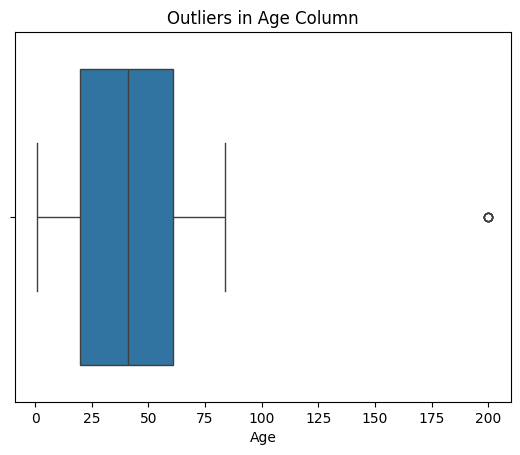

In [11]:
sns.boxplot(x = "Age",data = dataset)
plt.title('Outliers in Age Column')
plt.show()

#### Just exploring box plot

In [12]:
dataset['Subscription'].fillna("FREE")
dataset['Gender'].fillna(dataset['Gender'].mode()[0])
gender_map = {
    'F': 'Female',
    'female': 'Female',
    'M': 'Male',
    'male': 'Male'
}
Subscription_map = {
    'Premium': 'PREMIUM',
    'Basic': 'BASIC',
    'none': 'FREE',
    'Free': 'FREE',
    'NONE': 'FREE'
}
dataset['Subscription'] = dataset['Subscription'].replace(Subscription_map)
dataset['Gender'] = dataset['Gender'].replace(gender_map)

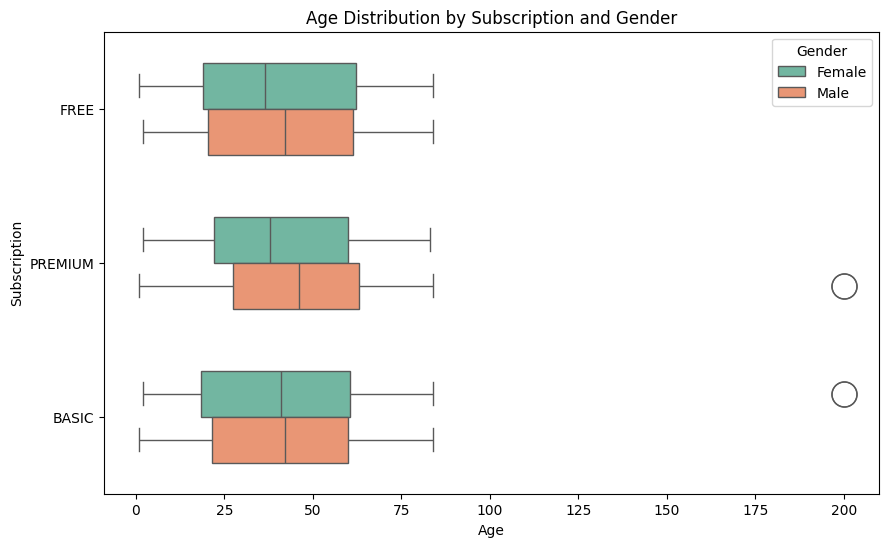

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=dataset,
    y="Subscription",
    x="Age",
    hue="Gender",      # Compares Age by Sub AND Gender
    palette="Set2",    # Nice color scheme
    width=0.6,         # Slimmer boxes
    fliersize=18,      # Makes your '200' age outliers bigger
    whis=1.5           # Standard IQR rule
)
plt.title("Age Distribution by Subscription and Gender")
plt.show()

#### Distribution plot

C:\Users\shikh\AppData\Local\Temp\ipykernel_21240\3953522691.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Age"])


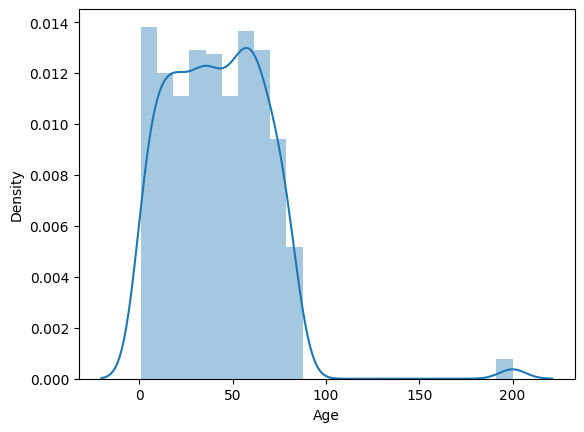

In [14]:
sns.distplot(dataset["Age"])
plt.show()

## Outlier removal using IQR method

In [15]:
dataset.shape

(761, 14)

### 1. Calculate Q1, Q3, and IQR

In [29]:
# 1. Calculate Q1, Q3, and IQR
Q1 = dataset['Age'].quantile(0.25)
Q3 = dataset['Age'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"IQR*1.5: {IQR*1.5}")

Q1: 20.0
Q3: 61.0
IQR: 41.0
IQR*1.5: 61.5


### 2. Define the bounds

In [17]:
# 2. Define the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: -41.5
Upper Bound: 122.5


### 3. Find the outliers

In [24]:
# 3. Find the outliers
outliers = dataset[(dataset['Age'] < lower_bound) | (dataset['Age'] > upper_bound)]
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total Outliers found: {len(outliers)}")
print(outliers[['PassengerId', 'Age']])

Lower Bound: -41.5
Upper Bound: 122.5
Total Outliers found: 5
     PassengerId    Age
22            23  200.0
42            43  200.0
389          390  200.0
436          437  200.0
715          716  200.0


In [26]:
new_dataset = dataset[dataset['Age']<upper_bound]
new_dataset.shape

(756, 14)

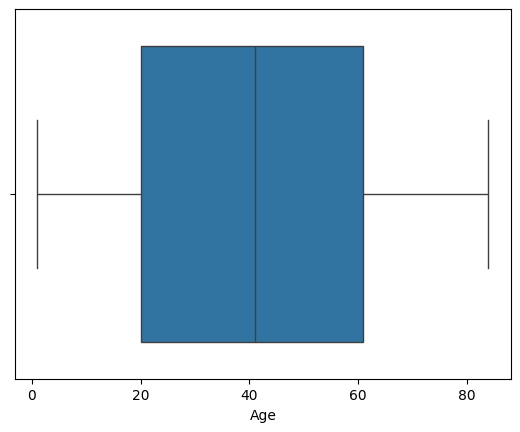

In [27]:
sns.boxplot(x = "Age",data = new_dataset)
plt.show()

C:\Users\shikh\AppData\Local\Temp\ipykernel_21240\2145277281.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_dataset["Age"])


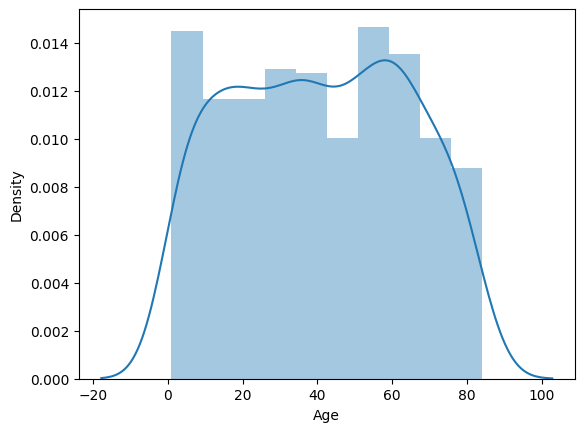

In [28]:
sns.distplot(new_dataset["Age"])
plt.show()

In [23]:
#This tells you the cutoffs for the bottom 10%, 25%, 50%, 75%, and top 90%. 
#It’s a great way to "feel" the shape of your data without looking at every single row!
dataset['Age'].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

0.10     8.0
0.25    20.0
0.50    41.0
0.75    61.0
0.90    74.0
Name: Age, dtype: float64

## Data prepping - Sanity check and data cleaning - Score column

In [31]:
dataset['Score'].isnull().sum()

np.int64(16)

In [32]:
dataset['Score'].describe()

count    745.000000
mean      69.242953
std       14.660633
min       17.000000
25%       59.000000
50%       70.000000
75%       80.000000
max      115.000000
Name: Score, dtype: float64

In [33]:
print(dataset['Score'].mean())
print(dataset['Score'].median())

69.24295302013422
70.0


### Fill null values in the column

In [35]:
dataset['Score'] = dataset['Score'].fillna(dataset['Score'].median())
dataset

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,52.0,104.22,Female,Tokyo,FREE,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,15.0,30.03,Female,London,PREMIUM,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,72.0,92.78,Female,New York,BASIC,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10
3,4,61.0,146.51,Male,London,BASIC,87.0,2020-01-04,user3@example.com,+1-555-9521,Yes,Average,D04,WELCOME50
4,5,21.0,96.74,Male,Tokyo,BASIC,73.0,2020-01-05,user4@example.com,+1-555-1242,False,Unknown,D01,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
756,757,60.0,67.70,Male,New York,BASIC,70.0,2020-12-06,user340@example.com,+1-555-2234,1,ok,D02,NaN
757,758,57.0,450.79,Male,New York,BASIC,82.0,2020-05-27,user147@example.com,+1-555-8248,0,ok,D03,NaN
758,759,9.0,320.40,Female,Paris,PREMIUM,58.0,2020-11-26,user330@example.com,+1-555-3250,True,ok,D03,SAVE10
759,760,51.0,229.23,Male,Paris,BASIC,61.0,2020-02-07,user37@example.com,+1-555-4198,Yes,Average,D04,NaN


### Inspecting the data with graphs and plots

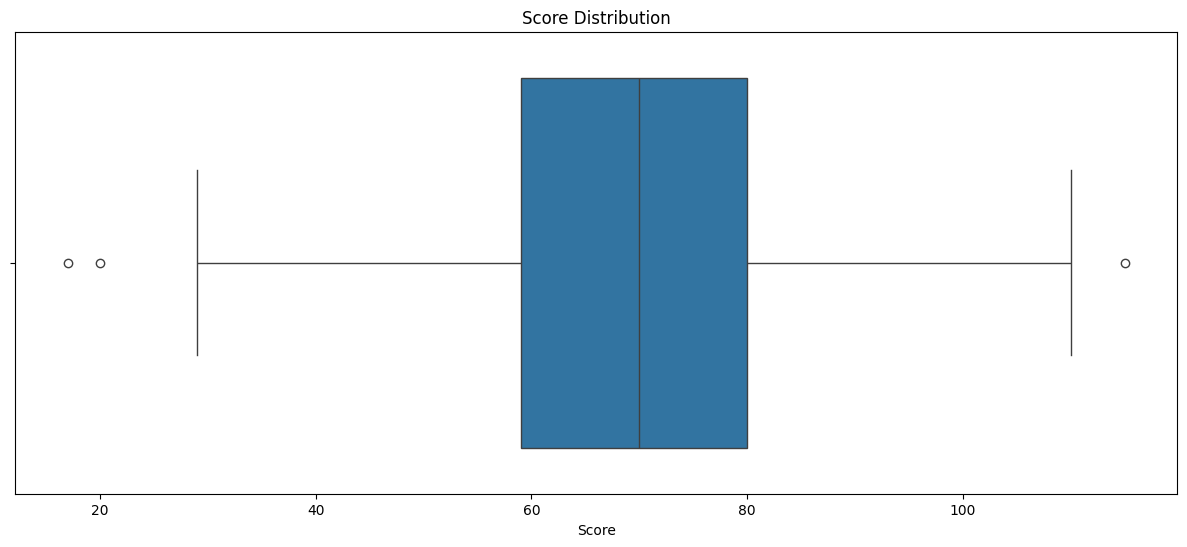

In [48]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='Score',data=dataset)
plt.title("Score Distribution")
plt.show()

C:\Users\shikh\AppData\Local\Temp\ipykernel_21240\2581013349.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Score'])


<Axes: xlabel='Score', ylabel='Density'>

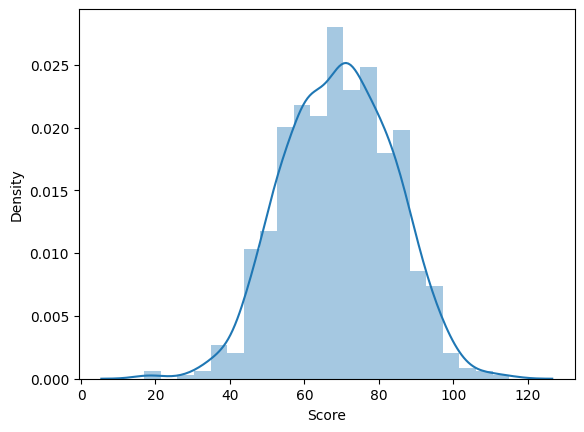

In [46]:
sns.distplot(dataset['Score'])

## Outlier identification & removal using Z-score method

### Manual method using 3*(Std. Dev) as the range

In [86]:
max_range = dataset['Score'].mean() + 3*dataset['Score'].std()
min_range = dataset['Score'].mean() - 3*dataset['Score'].std()
print(f"max_range : {max_range.round(2)} & min_range : {min_range.round(2)}")

max_range : 112.78 & min_range : 25.74


In [87]:
dataset_wo_outliers_1 = dataset[(dataset['Score'] > min_range) & (dataset['Score'] < max_range)]
dataset_wo_outliers_1.shape

(758, 14)

In [88]:
dataset_wo_outliers_2 = dataset[dataset['Score'].between(min_range, max_range)]
dataset_wo_outliers_2.shape

(758, 14)

In [89]:
outliers_z_score = dataset[(dataset['Score'] < min_range) | (dataset['Score'] > max_range)]
outliers_z_score

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
53,54,8.0,273.18,Male,New York,FREE,17.0,2020-02-23,user53@example.com,+1-555-9637,1,Average,D03,WELCOME50
531,532,17.0,137.28,Male,Tokyo,BASIC,115.0,2021-06-15,user531@example.com,+1-555-8473,none,Excellent,D01,SAVE10
608,609,16.0,344.81,Female,Berlin,FREE,20.0,2021-08-31,user608@example.com,+1-555-8356,No,Good,D04,WELCOME50


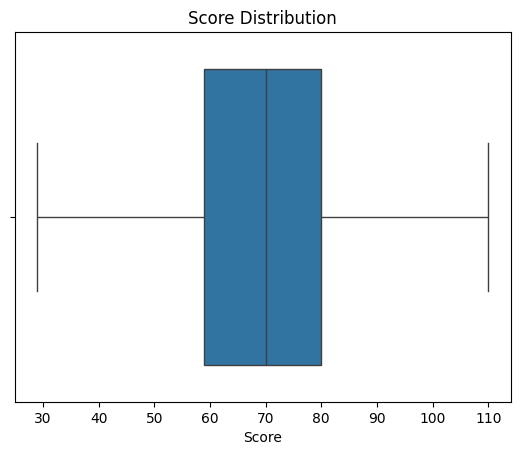

In [90]:
sns.boxplot(x='Score', data = dataset_wo_outliers_1)
plt.title("Score Distribution")
plt.show()

### Using the Z Score way

In [91]:
z_score = (dataset['Score']-dataset['Score'].mean())/(dataset['Score'].std())
z_score

0     -0.982971
1      0.878341
2      1.429841
3      1.223029
4      0.257904
         ...   
756    0.051092
757    0.878341
758   -0.776158
759   -0.569346
760   -0.707221
Name: Score, Length: 761, dtype: float64

In [92]:
abs(z_score)>3

0      False
1      False
2      False
3      False
4      False
       ...  
756    False
757    False
758    False
759    False
760    False
Name: Score, Length: 761, dtype: bool

In [93]:
outliers_1 = dataset[abs(z_score) > 3]
outliers_1

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
53,54,8.0,273.18,Male,New York,FREE,17.0,2020-02-23,user53@example.com,+1-555-9637,1,Average,D03,WELCOME50
531,532,17.0,137.28,Male,Tokyo,BASIC,115.0,2021-06-15,user531@example.com,+1-555-8473,none,Excellent,D01,SAVE10
608,609,16.0,344.81,Female,Berlin,FREE,20.0,2021-08-31,user608@example.com,+1-555-8356,No,Good,D04,WELCOME50


In [94]:
dataset_wo_outliers_2 = dataset[abs(z_score) < 3]
dataset_wo_outliers_2.shape

(758, 14)

### Using the scipy way

In [95]:
from scipy import stats

#### 1. Calculate the absolute Z-score for the column

In [97]:
# 1. Calculate the absolute Z-score for the column
# zscore calculates (x - mean) / std for every row
z_scores = abs(stats.zscore(dataset['Score']))
z_scores

array([0.98361703, 0.87891906, 1.43078161, 1.22383316, 0.2580737 ,
       1.25954831, 0.01785758, 1.63773007, 0.67197061, 0.22480603,
       0.67197061, 1.32853113, 0.70768576, 1.12158267, 0.53400497,
       0.74095343, 0.15582321, 0.91463422, 0.05112524, 0.5007373 ,
       0.77666858, 0.39603933, 0.77666858, 1.6044624 , 1.39751394,
       1.67344522, 0.2580737 , 0.18909088, 0.12010806, 0.60298779,
       1.22383316, 0.56972012, 0.46502215, 1.6044624 , 1.43078161,
       1.25954831, 0.70768576, 0.56972012, 1.53547958, 0.05112524,
       0.2580737 , 0.15582321, 1.6044624 , 2.05162698, 0.60298779,
       2.74145516, 0.8456514 , 1.0168847 , 0.80993625, 0.29378885,
       1.49976443, 0.43175449, 0.36277167, 3.60496413, 0.46502215,
       1.32853113, 0.56972012, 1.05259985, 0.36277167, 0.46502215,
       0.05112524, 0.74095343, 1.29281597, 0.36277167, 0.5007373 ,
       1.0168847 , 1.08586752, 0.80993625, 0.98361703, 0.46502215,
       0.12010806, 0.05112524, 0.56972012, 1.67344522, 0.74095

#### 2. Define your limit (standard is 3)

In [98]:
# 2. Define your limit (standard is 3)
threshold = 3

#### 3. Create a clean dataset by keeping only rows beneath the threshold

In [100]:
outliers_3 = dataset[z_scores > threshold]
outliers_3

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
53,54,8.0,273.18,Male,New York,FREE,17.0,2020-02-23,user53@example.com,+1-555-9637,1,Average,D03,WELCOME50
531,532,17.0,137.28,Male,Tokyo,BASIC,115.0,2021-06-15,user531@example.com,+1-555-8473,none,Excellent,D01,SAVE10
608,609,16.0,344.81,Female,Berlin,FREE,20.0,2021-08-31,user608@example.com,+1-555-8356,No,Good,D04,WELCOME50


In [102]:
# 3. Create a clean dataset by keeping only rows beneath the threshold
dataset_wo_outliers_3 = dataset[z_scores < threshold]
dataset_wo_outliers_3.shape

(758, 14)

#### Summary

In [103]:
print(f"Original rows: {len(dataset)}")
print(f"Cleaned rows: {len(dataset_wo_outliers_3)}")
print(f"Outliers removed: {len(dataset) - len(dataset_wo_outliers_3)}")

Original rows: 761
Cleaned rows: 758
Outliers removed: 3
